# Classification of complex networks (Lab 7)

**Content Table**

- [Imports & Support data](#imports)
- [Support Functions](#support-funcions)
- [Biological Networks](#biological)
- [Social Networks](#social)
- [Technological Networks](#tech)
- [Resultados](#results)

## Imports & Support data
<a id="imports"></a>

In [80]:
! pip install networkx zstandard scikit-learn tabulate requests pandas numpy matplotlib igraph -q

In [81]:
import os
import random
import warnings
from collections import Counter, defaultdict
from concurrent.futures import ProcessPoolExecutor
from io import BytesIO
from pathlib import Path
from urllib.parse import urlparse

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import requests

from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import RobustScaler
from tabulate import tabulate

from scipy.cluster.hierarchy import linkage

In [82]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

In [83]:
datasets = {}

In [84]:
datasets["biological"] = [
    {
        "name": "celegans_interactomes/wi2007",
        "path": "https://networks.skewed.de/net/celegans_interactomes/files/wi2007.xml.zst"
    },
    {
        "name": "collins_yeast",
        "path": "https://networks.skewed.de/net/collins_yeast/files/collins_yeast.xml.zst"
    },
    {
        "name": "interactome_yeast",
        "path": "https://networks.skewed.de/net/interactome_yeast/files/interactome_yeast.xml.zst",
    },
    {
        "name": "malaria_genes/HVR_1",
        "path": "https://networks.skewed.de/net/malaria_genes/files/HVR_1.xml.zst"
    },
]

In [85]:
datasets["social"]= [
    {
        "name": "netscience",
        "path": "https://networks.skewed.de/net/netscience/files/netscience.xml.zst"
    },
    {
        "name": "crime",
        "path": "https://networks.skewed.de/net/crime/files/crime.xml.zst"
    },
    {
        "name": "foursquare/NYC_restaurant_checkin",
        "path": "https://networks.skewed.de/net/foursquare/files/NYC_restaurant_checkin.xml.zst"
    },
    {
        "name": "foursquare/NYC_restaurant_tips",
        "path": "https://networks.skewed.de/net/foursquare/files/NYC_restaurant_tips.xml.zst"
    },
]

In [86]:
datasets["technological"] = [
    {
        "name": "internet_as",
        "path": "https://networks.skewed.de/net/internet_as/files/internet_as.xml.zst"
    },
    {
        "name": "jdk",
        "path": "https://networks.skewed.de/net/jdk/files/jdk.xml.zst"
    },
    {
        "name": "gnutella/04",
        "path": "https://networks.skewed.de/net/gnutella/files/04.xml.zst"
    },
]

## Support Functions
<a id="support-functions"></a>

### download_xml_zst

Downloads a `.xml.zst` file from a given URL into a local directory, creating the directory if needed.

It validates that the URL points to an `.xml.zst` file, streams the download in chunks, and returns the saved file path as a `Path` object.


In [87]:
def download_xml_zst(url: str, output_dir: str = "data/raw") -> Path:
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)

    filename = Path(urlparse(url).path).name

    if not filename.endswith(".xml.zst"):
        raise ValueError(f"URL does not point to an .xml.zst file: {filename}")

    file_path = output_path / filename

    response = requests.get(url, stream=True, timeout=60)
    response.raise_for_status()

    with open(file_path, "wb") as f:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)

    return file_path

### plot_network

Generates a 2D visualization of a graph using a spring layout for node positioning.

It customizes styling (colors, sizes, background), renders nodes and edges with Matplotlib and NetworkX, displays the plot, and returns the computed node positions.


In [88]:
def plot_network(G: nx.Graph):
    pos = nx.spring_layout(
        G,
        seed=42,
        k=0.01,
        iterations=300,
    )

    fig, ax = plt.subplots(figsize=(10, 10))

    background_color = "#cfcfcf"

    fig.patch.set_facecolor(background_color)
    ax.set_facecolor(background_color)

    nx.draw_networkx_edges(
        G,
        pos,
        ax=ax,
        edge_color="#5a5a5a",
        width=0.4,
        alpha=0.7,
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_size=22,
        node_color="#b72b2f",
        edgecolors="#8a1f22",
        linewidths=0.3,
        alpha=0.95,
    )

    ax.set_axis_off()
    plt.tight_layout(pad=0)
    plt.show()

    return pos

### read_xml_zst_to_networkx

Reads a local compressed `.xml.zst` GraphML file and converts it into a NetworkX graph.

It validates the file, decompresses it, patches unsupported GraphML attribute types, optionally removes incompatible tags, and can convert the graph to undirected or relabel nodes as integers.


In [89]:
from pathlib import Path
from io import BytesIO
import re
import zstandard as zstd
import networkx as nx


def read_xml_zst_to_networkx(
    file_path: str | Path,
    relabel_to_int: bool = False,
) -> nx.Graph:
    file_path = Path(file_path)

    if not file_path.exists():
        raise FileNotFoundError(f"File not found: {file_path}")

    if file_path.suffixes[-2:] != [".xml", ".zst"]:
        raise ValueError(f"Expected a .xml.zst file, got: {file_path}")

    dctx = zstd.ZstdDecompressor()

    with open(file_path, "rb") as compressed_file:
        with dctx.stream_reader(compressed_file) as reader:
            graphml_data = reader.read()

    graphml_text = graphml_data.decode("utf-8", errors="replace")

    valid_graphml_types = {
        "boolean",
        "int",
        "long",
        "float",
        "double",
        "string",
    }

    def patch_attr_type(match):
        attr_type = match.group(1)
        if attr_type in valid_graphml_types:
            return match.group(0)
        return 'attr.type="string"'

    graphml_text = re.sub(
        r'attr\.type="([^"]+)"',
        patch_attr_type,
        graphml_text,
    )

    graphml_text = re.sub(
        r"<y:.*?</y:.*?>",
        "",
        graphml_text,
        flags=re.DOTALL,
    )

    graph = nx.read_graphml(BytesIO(graphml_text.encode("utf-8")))

    graph = nx.Graph(graph)
    graph.remove_edges_from(nx.selfloop_edges(graph))

    if relabel_to_int:
        graph = nx.convert_node_labels_to_integers(
            graph,
            first_label=0,
            ordering="default",
        )

    return graph

### feature_extractor

Extracts structural metrics from a NetworkX graph and returns them as a dictionary.

It computes node/edge counts, degree moments and variance, clustering, shortest path, assortativity, and the giant component fraction.


In [110]:
def feature_extractor(G: nx.Graph) -> dict[str, float]:
    # =========================================================================
    # SANITIZAÇÃO DE TOPOLOGIA
    # =========================================================================
    H = nx.Graph()
    H.add_nodes_from(G.nodes())
    H.add_edges_from(G.edges())
    H.remove_edges_from(nx.selfloop_edges(H))
    G = H

    n = G.number_of_nodes()

    # =========================================================================
    # MOMENTOS DE GRAU — VETORIZADO
    # =========================================================================
    if n == 0:
        degrees = np.array([], dtype=np.float64)
        k1 = 0.0
        k2 = 0.0
    else:
        degrees = np.array([d for _, d in G.degree()], dtype=np.float64)
        k1 = float(degrees.mean())
        k2 = float((degrees ** 2).mean())

    # =========================================================================
    # GIANT COMPONENT FRACTION
    # =========================================================================
    def giant_component_fraction(G: nx.Graph) -> float:
        if G.number_of_nodes() == 0:
            return 0.0
        largest_cc = max(nx.connected_components(G), key=len)
        return len(largest_cc) / G.number_of_nodes()

    # =========================================================================
    # AVERAGE SHORTEST PATH — AMOSTRADO PARA REDES GRANDES
    # =========================================================================
    def average_shortest_path(G: nx.Graph) -> float:
        if G.number_of_nodes() == 0:
            return 0.0

        if nx.is_connected(G):
            target = G
        else:
            target = G.subgraph(max(nx.connected_components(G), key=len)).copy()

        n_target = target.number_of_nodes()
        if n_target <= 1:
            return 0.0
        if n_target <= 500:
            return nx.average_shortest_path_length(target)

        # Amostragem com seed fixa para reprodutibilidade
        rng = random.Random(42)
        sample = rng.sample(list(target.nodes()), 500)
        lengths = []
        for node in sample:
            lengths.extend(nx.single_source_shortest_path_length(target, node).values())
        return sum(lengths) / len(lengths) if lengths else 0.0

    # =========================================================================
    # DEGREE ASSORTATIVITY — SEGURO CONTRA DEGENERESCÊNCIAS
    # =========================================================================
    def safe_assortativity(G: nx.Graph) -> float:
        if G.number_of_edges() == 0:
            return 0.0
        if degrees.size == 0 or degrees.var() == 0:
            return 0.0

        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", RuntimeWarning)
                val = nx.degree_assortativity_coefficient(G)
            return float(val) if not np.isnan(val) else 0.0
        except (ZeroDivisionError, ValueError):
            return 0.0

    # =========================================================================
    # AVERAGE CLUSTERING — AMOSTRADO PARA REDES GRANDES
    # =========================================================================
    def sampled_clustering(G: nx.Graph, sample_size: int = 1000) -> float:
        n_g = G.number_of_nodes()
        if n_g == 0:
            return 0.0
        if n_g <= sample_size:
            return nx.average_clustering(G)
        rng = random.Random(42)
        sample = rng.sample(list(G.nodes()), sample_size)
        return nx.average_clustering(G, nodes=sample)

    return {
        "nodes":                    n,
        "edges":                    G.number_of_edges(),
        "k1":                       k1,
        "k2":                       k2,
        "degree_variance":          k2 - k1 ** 2,
        "average_clustering":       sampled_clustering(G),
        "average_shortest_path":    average_shortest_path(G),
        "degree_assortativity":     safe_assortativity(G),
        "giant_component_fraction": giant_component_fraction(G),
    }

In [111]:
from concurrent.futures import ProcessPoolExecutor
import multiprocessing as mp


def extract_feature_job(args):
    net, net_id, network_name = args

    tmp = feature_extractor(net)

    tmp.update({
        "type": net_id,
        "network": network_name,
    })

    return tmp

### generate_random_networks_from_graph

A função `generate_random_networks_from_graph` recebe o grafo original `G` e gera cinco modelos nulos distintos. Cada um desses modelos representa uma hipótese diferente sobre os mecanismos estruturais que poderiam ter dado origem à rede original. Para garantir que os resultados sejam reprodutíveis, todos os modelos são construídos com `seed=42`. Além disso, antes de extrair qualquer parâmetro, o grafo base é convertido para não direcionado e passa por uma limpeza para a remoção de loops (self-loops).

#### erdos_renyi

Este modelo é gerado através de `gnm_random_graph(n, m)`, distribuindo exatamente `m` arestas de forma uniforme e aleatória entre os `n` nós. Ele funciona como o nosso nível mais básico de comparação, já que não possui heterogeneidade de graus, estruturas de comunidade ou anexação preferencial. Na prática, ele serve como um marco zero: se a rede original for indistinguível deste modelo, significa que ela não possui nenhuma estrutura organizacional relevante além da sua densidade.

#### configuration_model

O objetivo aqui é preservar a sequência exata de graus do grafo original, conectando as "pontas" (stubs) das arestas de maneira aleatória. Este é considerado o modelo nulo estrutural mais fiel, pois mantém intactos tanto o `k1` quanto a distribuição de graus. Como os loops são removidos após a geração, a contagem final de arestas pode variar um pouco em relação à original. Se o classificador escolher este modelo com frequência, isso indica que a distribuição de graus, por si só, já explica a maior parte da topologia da rede.

#### barabasi_albert

Este modelo simula o crescimento da rede adicionando novos nós de forma iterativa, cada um com `m_ba` arestas que se conectam preferencialmente aos nós que já possuem graus elevados. O valor de `m_ba` é calculado como `avg_degree / 2` (dentro dos limites válidos). O foco aqui é capturar o comportamento "scale-free" e a formação de hubs, características muito comuns em redes biológicas e sociais. Vale notar que o número de arestas será diferente do original, já que o BA é um modelo de crescimento e não foca em preservar o volume exato de conexões.

#### watts_strogatz

O processo começa com um anel regular onde cada nó tem `k_ws` vizinhos e, em seguida, cada aresta é religada aleatoriamente com uma probabilidade de `0.1`. O resultado é uma rede de "mundo pequeno", caracterizada por um alto coeficiente de agrupamento (clustering) e caminhos curtos entre os nós. O parâmetro `k_ws` é derivado do grau médio da rede original, arredondado para o número par mais próximo. Este modelo é essencial para testar se a rede original exibe propriedades típicas de redes de pequeno mundo.

#### stochastic_block_model

Neste modelo, dividimos os `n` nós em quatro blocos de tamanhos iguais. Definimos uma probabilidade de conexão interna (`p_in = p * 4`) e uma probabilidade de conexão entre blocos (`p_out = p * 0.25`), onde `p` representa a densidade global de arestas da rede original. O SBM foca especificamente na estrutura de comunidades. Se o classificador apontar para este modelo, temos um forte indício de que a rede original possui uma organização modular significativa que os outros modelos não conseguem replicar.

In [91]:
SEEDS_DEFAULT = [1, 7, 42, 123, 314, 1618, 2718, 9999, 31415]


# =============================================================================
# HELPERS
# =============================================================================

def _topology_only(G_in: nx.Graph) -> nx.Graph:
    """Descarta atributos e self-loops. Necessário pra evitar crash em redes
    com atributos string vindas do GraphML reader."""
    H = nx.Graph()
    H.add_nodes_from(G_in.nodes())
    H.add_edges_from(G_in.edges())
    H.remove_edges_from(nx.selfloop_edges(H))
    return H


def _sampled_clustering(H: nx.Graph, sample_size: int = 1000, seed: int = 42) -> float:
    """Clustering amostrado para evitar O(n*<k>^2) em redes grandes."""
    n_h = H.number_of_nodes()
    if n_h == 0:
        return 0.0
    if n_h <= sample_size:
        return nx.average_clustering(H)
    rng = random.Random(seed)
    sample = rng.sample(list(H.nodes()), sample_size)
    return nx.average_clustering(H, nodes=sample)


def _select_seeds(n: int) -> list[int]:
    """Ajusta seeds pelo tamanho da rede para manter custo viável."""
    if n > 100_000:
        return SEEDS_DEFAULT[:3]
    if n > 20_000:
        return SEEDS_DEFAULT[:5]
    return SEEDS_DEFAULT


# =============================================================================
# ERDOS-RENYI — gnm e gnp
# =============================================================================

def _gen_er_one(n: int, m: int, p_er: float, seed: int) -> list[nx.Graph]:
    return [
        nx.gnm_random_graph(n=n, m=m, seed=seed),
        nx.gnp_random_graph(n=n, p=p_er, seed=seed),
    ]


def gen_erdos_renyi(n: int, m: int, seeds: list[int],
                    pool: ProcessPoolExecutor | None = None) -> list[nx.Graph]:
    p_er = (2 * m) / (n * (n - 1))
    if pool is None:
        return [g for s in seeds for g in _gen_er_one(n, m, p_er, s)]
    futures = [pool.submit(_gen_er_one, n, m, p_er, s) for s in seeds]
    return [g for f in futures for g in f.result()]


# =============================================================================
# CONFIGURATION MODEL — classic e expected_degree
# =============================================================================

def _gen_cm_one(degree_sequence: list[int], w: list[float],
                k1_target: float, seed: int) -> list[nx.Graph]:
    graphs = []
    G_raw = nx.configuration_model(degree_sequence, seed=seed)
    G_classic = nx.Graph(G_raw)
    G_classic.remove_edges_from(nx.selfloop_edges(G_classic))
    k1_classic = np.mean([d for _, d in G_classic.degree()])
    if abs(k1_classic - k1_target) / k1_target <= 0.05:
        graphs.append(G_classic)
    graphs.append(nx.expected_degree_graph(w, seed=seed, selfloops=False))
    return graphs


def gen_configuration_model(degree_sequence: list[int], seeds: list[int],
                             pool: ProcessPoolExecutor | None = None) -> list[nx.Graph]:
    w = [float(d) for d in degree_sequence]
    k1_target = float(np.mean(degree_sequence))
    if pool is None:
        return [g for s in seeds for g in _gen_cm_one(degree_sequence, w, k1_target, s)]
    futures = [pool.submit(_gen_cm_one, degree_sequence, w, k1_target, s) for s in seeds]
    return [g for f in futures for g in f.result()]


# =============================================================================
# BARABASI-ALBERT — m-1, m, m+1, powerlaw_cluster
# =============================================================================

def _fit_ba_m(n: int, target_edges: int, seed: int = 42) -> int:
    m_estimate = max(1, target_edges // n)
    candidates = range(max(1, m_estimate - 2), m_estimate + 4)
    best_m, best_diff = m_estimate, float('inf')
    for m_try in candidates:
        if m_try >= n:
            continue
        G_test = nx.barabasi_albert_graph(n=n, m=m_try, seed=seed)
        diff = abs(G_test.number_of_edges() - target_edges)
        if diff < best_diff:
            best_diff, best_m = diff, m_try
    return best_m


def _gen_ba_one(n: int, m_ba: int, seed: int) -> list[nx.Graph]:
    graphs = []
    for m_try in [max(1, m_ba - 1), m_ba, m_ba + 1]:
        if m_try < n:
            graphs.append(nx.barabasi_albert_graph(n=n, m=m_try, seed=seed))
    if m_ba < n:
        graphs.append(nx.powerlaw_cluster_graph(n=n, m=m_ba, p=0.3, seed=seed))
    return graphs


def gen_barabasi_albert(n: int, m: int, seeds: list[int],
                        pool: ProcessPoolExecutor | None = None) -> list[nx.Graph]:
    m_ba = _fit_ba_m(n, m)
    if pool is None:
        return [g for s in seeds for g in _gen_ba_one(n, m_ba, s)]
    futures = [pool.submit(_gen_ba_one, n, m_ba, s) for s in seeds]
    return [g for f in futures for g in f.result()]


# =============================================================================
# WATTS-STROGATZ — p*0.5, p, p*1.5, newman_watts
# =============================================================================

def _compute_k_ws(avg_degree: float, n: int) -> int:
    k_ws = max(4, round(avg_degree))
    k_ws = k_ws if k_ws % 2 == 0 else k_ws + 1
    k_ws = min(k_ws, n - 1)
    k_ws = k_ws if k_ws % 2 == 0 else k_ws - 1
    return k_ws


def _fit_ws_p(n: int, k: int, target: float, seed: int = 42,
              tol: float = 0.02, max_iter: int = 8) -> float:
    c_max = _sampled_clustering(nx.watts_strogatz_graph(n=n, k=k, p=0.0, seed=seed))
    c_min = _sampled_clustering(nx.watts_strogatz_graph(n=n, k=k, p=1.0, seed=seed))

    if target <= c_min:
        return 1.0
    if target >= c_max:
        return 0.0

    lo, hi = 0.0, 1.0
    for _ in range(max_iter):
        mid = (lo + hi) / 2
        G_test = nx.watts_strogatz_graph(n=n, k=k, p=mid, seed=seed)
        c = _sampled_clustering(G_test)
        if abs(c - target) < tol:
            return mid
        if c < target:
            hi = mid
        else:
            lo = mid
    return mid


def _gen_ws_one(n: int, k_ws: int, p_ws: float,
                p_variants: list[float], seed: int) -> list[nx.Graph]:
    graphs = []
    for p in p_variants:
        graphs.append(nx.watts_strogatz_graph(n=n, k=k_ws, p=p, seed=seed))
    graphs.append(nx.newman_watts_strogatz_graph(n=n, k=k_ws, p=p_ws, seed=seed))
    return graphs


def gen_watts_strogatz(n: int, avg_degree: float, target_clustering: float,
                        seeds: list[int],
                        pool: ProcessPoolExecutor | None = None) -> list[nx.Graph]:
    k_ws = _compute_k_ws(avg_degree, n)
    p_ws = _fit_ws_p(n, k_ws, target_clustering)
    p_variants = [
        max(0.0, p_ws * 0.5),
        p_ws,
        min(1.0, p_ws * 1.5),
    ]
    if pool is None:
        return [g for s in seeds for g in _gen_ws_one(n, k_ws, p_ws, p_variants, s)]
    futures = [pool.submit(_gen_ws_one, n, k_ws, p_ws, p_variants, s) for s in seeds]
    return [g for f in futures for g in f.result()]


# =============================================================================
# STOCHASTIC BLOCK MODEL — 3 resoluções × seeds
# =============================================================================

def _louvain_one(G: nx.Graph, resolution: float, seed: int = 42) -> tuple[float, list]:
    """Helper paralelizável: retorna (resolution, communities)."""
    comms = list(nx.community.louvain_communities(
        G, seed=seed, weight=None, resolution=resolution
    ))
    return (resolution, comms)


def _louvain_cache(G: nx.Graph, resolutions: list[float],
                    pool: ProcessPoolExecutor | None = None) -> dict:
    """Calcula Louvain para 3 resoluções em paralelo (gargalo principal)."""
    if pool is None:
        return {r: _louvain_one(G, r)[1] for r in resolutions}
    futures = [pool.submit(_louvain_one, G, r) for r in resolutions]
    return {r: comms for f in futures for r, comms in [f.result()]}


def _build_sbm_fast(G: nx.Graph, communities: list, n: int, seed: int) -> nx.Graph:
    """SBM com amostragem vetorizada de arestas inter-bloco (~100× mais rápido)."""
    MIN_SIZE = 3
    main_comms = [set(c) for c in communities if len(c) >= MIN_SIZE]
    small_nodes = set().union(*[c for c in communities if len(c) < MIN_SIZE])
    if small_nodes and main_comms:
        max(main_comms, key=len).update(small_nodes)
    if not main_comms:
        main_comms = [set(c) for c in communities]

    sizes = [len(c) for c in main_comms]
    n_blocks = len(main_comms)

    node_to_block = {}
    for i, c in enumerate(main_comms):
        for node in c:
            node_to_block[node] = i

    intra_edges = defaultdict(list)
    inter_edge_count = defaultdict(int)
    for u, v in G.edges():
        b1 = node_to_block.get(u, 0)
        b2 = node_to_block.get(v, 0)
        if b1 == b2:
            intra_edges[b1].append((u, v))
        else:
            key = (min(b1, b2), max(b1, b2))
            inter_edge_count[key] += 1

    rng = np.random.default_rng(seed)
    H = nx.Graph()

    node_remap = {}
    block_nodes = [[] for _ in range(n_blocks)]
    new_id = 0
    for i, comm in enumerate(main_comms):
        for node in comm:
            node_remap[node] = new_id
            block_nodes[i].append(new_id)
            new_id += 1
    H.add_nodes_from(range(new_id))

    # Intra: expected_degree_graph (preserva hubs intra-bloco)
    for i in range(n_blocks):
        if len(block_nodes[i]) < 2:
            continue
        intra_deg = [0] * len(block_nodes[i])
        local_idx = {nid: idx for idx, nid in enumerate(block_nodes[i])}
        for u, v in intra_edges.get(i, []):
            intra_deg[local_idx[node_remap[u]]] += 1
            intra_deg[local_idx[node_remap[v]]] += 1
        if sum(intra_deg) == 0:
            continue
        H_intra = nx.expected_degree_graph(intra_deg, seed=seed + i, selfloops=False)
        for u_local, v_local in H_intra.edges():
            H.add_edge(block_nodes[i][u_local], block_nodes[i][v_local])

    # Inter: amostragem vetorizada
    for (i, j), count in inter_edge_count.items():
        if count == 0 or len(block_nodes[i]) == 0 or len(block_nodes[j]) == 0:
            continue
        block_i_arr = np.array(block_nodes[i])
        block_j_arr = np.array(block_nodes[j])
        oversample = max(count * 2, 10)
        u_idx = rng.integers(0, len(block_i_arr), size=oversample)
        v_idx = rng.integers(0, len(block_j_arr), size=oversample)
        seen = set()
        added = 0
        for ui, vi in zip(u_idx, v_idx):
            u, v = int(block_i_arr[ui]), int(block_j_arr[vi])
            key = (min(u, v), max(u, v))
            if key not in seen and not H.has_edge(u, v):
                seen.add(key)
                H.add_edge(u, v)
                added += 1
                if added >= count:
                    break

    return H


def _gen_sbm_one(G_base: nx.Graph, communities: list,
                 n: int, seed: int) -> nx.Graph:
    return _build_sbm_fast(G_base, communities, n, seed)


def gen_stochastic_block_model(G_base: nx.Graph, n: int, seeds: list[int],
                                resolutions: tuple = (0.7, 1.0, 1.5),
                                pool: ProcessPoolExecutor | None = None) -> list[nx.Graph]:
    cache = _louvain_cache(G_base, list(resolutions), pool=pool)
    tasks = [(cache[r], s) for s in seeds for r in resolutions]
    if pool is None:
        return [_gen_sbm_one(G_base, comms, n, s) for comms, s in tasks]
    futures = [pool.submit(_gen_sbm_one, G_base, comms, n, s) for comms, s in tasks]
    return [f.result() for f in futures]


# =============================================================================
# ENTRYPOINT
# =============================================================================

def generate_random_networks_from_graph(
    G: nx.Graph,
    seeds: list[int] | None = None,
    n_workers: int | None = None,
) -> dict[str, list[nx.Graph]]:
    """
    Gera múltiplas realizações de cada um dos 5 modelos nulos em paralelo.

    Args:
        G:         Grafo de referência
        seeds:     Lista de seeds (default: ajustado pelo tamanho de G)
        n_workers: Número de processos. None = auto (cpu_count - 1).
                   Use 1 para forçar serial.

    Returns:
        dict mapeando nome do modelo -> list[nx.Graph]
    """
    G_base = _topology_only(G.to_undirected() if G.is_directed() else G)
    n = G_base.number_of_nodes()
    m = G_base.number_of_edges()
    avg_degree = (2 * m) / n
    degree_sequence = [d for _, d in G_base.degree()]
    target_clustering = _sampled_clustering(G_base)

    if seeds is None:
        seeds = _select_seeds(n)

    if n_workers is None:
        n_workers = max(1, (os.cpu_count() or 2) - 1)

    # Modo serial — sem overhead de pool
    if n_workers == 1:
        return {
            "erdos_renyi":            gen_erdos_renyi(n, m, seeds),
            "configuration_model":    gen_configuration_model(degree_sequence, seeds),
            "barabasi_albert":        gen_barabasi_albert(n, m, seeds),
            "watts_strogatz":         gen_watts_strogatz(n, avg_degree, target_clustering, seeds),
            "stochastic_block_model": gen_stochastic_block_model(G_base, n, seeds),
        }

    # Modo paralelo — pool compartilhado entre todos os geradores
    # Paraleliza POR SEED (granularidade alta = melhor uso dos cores)
    with ProcessPoolExecutor(max_workers=n_workers) as pool:
        return {
            "erdos_renyi":            gen_erdos_renyi(n, m, seeds, pool=pool),
            "configuration_model":    gen_configuration_model(degree_sequence, seeds, pool=pool),
            "barabasi_albert":        gen_barabasi_albert(n, m, seeds, pool=pool),
            "watts_strogatz":         gen_watts_strogatz(n, avg_degree, target_clustering, seeds, pool=pool),
            "stochastic_block_model": gen_stochastic_block_model(G_base, n, seeds, pool=pool),
        }

### plot_degree_distribution_loglog

In [92]:
def plot_degree_distribution_loglog(networks: list):
    fig, axes = plt.subplots(1, len(networks), figsize=(5 * len(networks), 4))
    fig.suptitle("Degree Distribution — Original Networks", fontsize=13)

    for ax, entry in zip(axes, networks):
        G    = entry["networks"]["original"][0]
        name = entry["name"]

        degrees = [d for _, d in G.degree()]
        counts  = Counter(degrees)

        x = np.array(sorted(counts.keys()))
        y = np.array([counts[k] for k in x]) / len(degrees)

        ax.scatter(x, y, s=15, alpha=0.8, edgecolors="none", label="P(k)")

        # Fit power law reference line
        log_x = np.log(x[x > 0])
        log_y = np.log(y[x > 0])
        coeffs = np.polyfit(log_x, log_y, 1)
        gamma  = coeffs[0]
        x_line = np.linspace(max(x.min(), 1), x.max(), 100)  # fix: evita x=0
        y_line = np.exp(coeffs[1]) * x_line ** gamma
        ax.plot(x_line, y_line, "r--", linewidth=1, alpha=0.7, label=f"γ = {abs(gamma):.2f}")

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("Degree (k)")
        ax.set_ylabel("P(k)")
        ax.set_title(name, fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(True, which="both", linestyle="--", linewidth=0.4, alpha=0.5)

    plt.tight_layout()
    plt.show()

### plot_pca_projection

In [93]:
def plot_pca_projection(df: pd.DataFrame):
    networks = df["network"].unique()
    fig, axes = plt.subplots(1, len(networks), figsize=(6 * len(networks), 4),
                              squeeze=False)
    axes = axes.flatten()
    fig.suptitle("PCA Projection — Models vs Original", fontsize=13)

    style_map = {
        "erdos_renyi":               ("s", "#1f3b73", "ER"),
        "watts_strogatz":            ("o", "#1d6b3f", "WS"),
        "barabasi_albert":           ("^", "#d97706", "BA"),
        "configuration_model":       ("v", "#b91c1c", "CM"),
        "stochastic_block_model":    ("D", "#eab308", "SBM"),
        "hierarchical_random_graph": ("H", "#1c8200", "HRG"),
    }

    feature_cols = [c for c in df.columns if c not in ("network", "type", "nodes", "edges")]

    for ax, name in zip(axes, networks):
        table = df[df["network"] == name].reset_index(drop=True)
        X = table[feature_cols].values
        types = table["type"].values

        X_scaled = RobustScaler().fit_transform(X)
        pca = PCA(n_components=2, random_state=42)
        X_pca = pca.fit_transform(X_scaled)
        var_total = pca.explained_variance_ratio_.sum()

        for type_name, (marker, color, label) in style_map.items():
            mask = types == type_name
            if mask.any():
                ax.scatter(X_pca[mask, 0], X_pca[mask, 1], marker=marker, color=color,
                           s=80, edgecolors="black", linewidths=0.5, label=label, alpha=0.85)

        orig_mask = types == "original"
        if orig_mask.any():
            ax.scatter(X_pca[orig_mask, 0], X_pca[orig_mask, 1], marker="*",
                       color="#dc2626", s=300, edgecolors="black", linewidths=0.8,
                       label="Real", zorder=5)

        ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
        ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
        ax.set_title(f"{name} — {var_total*100:.0f}% var", fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.5)

    plt.tight_layout()
    plt.show()

### Classificadores

#### KNN (k-Nearest Neighbors)

Este classificador identifica a rede original utilizando a lógica de vizinhos mais próximos ($k=5$) dentro do espaço de atributos já padronizado. Antes de qualquer cálculo, removi as colunas de "nós" e "arestas". Fiz isso porque o número de nós é constante em todas as gerações e o volume de arestas é redundante em relação ao atributo `k1` ($2m/n$). Manter esses dados acabaria distorcendo o escalonador e adicionando ruído onde precisamos de sinal.

Para a padronização, utilizei o `RobustScaler` (baseado na mediana e no IQR), que se comporta de forma muito mais estável que o `StandardScaler` quando as classes têm dispersões desiguais. Além disso, o classificador utiliza votação ponderada pela distância (`weights="distance"`), o que dá mais peso aos vizinhos que estão realmente próximos do nosso ponto de teste.

**Confiança:** É calculada pela proporção de votos ponderados da classe vencedora entre os 5 vizinhos, variando de $0$ a $1$. Um valor de $1.0$ significa que todos os vizinhos próximos pertencem à mesma classe (um cluster bem definido ao redor da rede original). Já valores abaixo de $0.4$ indicam que os vizinhos estão espalhados entre várias classes, sinalizando uma ambiguidade local.

#### Classificador por Centroide

Este método calcula a distância euclidiana da rede original até o centroide (a média) de cada grupo de modelos gerados. A classe prevista é simplesmente aquela cujo "centro de massa" está mais perto da rede original no espaço de atributos.

Ele funciona como um excelente contraponto ao KNN. Enquanto o KNN foca na vizinhança imediata e em realizações específicas, o Centroide olha para a posição típica da classe como um todo. Quando os dois concordam, temos um resultado muito robusto; quando divergem, é um sinal claro de que estamos lidando com um caso de fronteira que exige uma análise mais detalhada.

**Confiança:** Aqui, a métrica é o intervalo relativo entre o primeiro e o segundo centroide mais próximos, calculado como $1 - (dist\_vencedor / dist\_segundo)$. Um valor próximo de $1.0$ mostra que a classe escolhida está isolada e muito mais perto que as outras. Se o valor estiver próximo de $0.0$, significa que duas ou mais classes estão praticamente à mesma distância da rede original, indicando que o modelo está incerto sobre a classificação.

In [94]:
def _prepare_data(df: pd.DataFrame, network_name: str):
    table = df[df["network"] == network_name].drop(columns="network").reset_index(drop=True)
    original = table[table["type"] == "original"]
    rnd = table[table["type"] != "original"]

    # Balanceia: subamostra cada classe para o tamanho da menor
    min_per_class = rnd["type"].value_counts().min()
    rnd = (
        rnd.groupby("type", group_keys=False)
           .sample(n=min_per_class, random_state=42)
           .reset_index(drop=True)
    )

    feature_cols = [c for c in table.columns if c not in ("type", "nodes", "edges")]
    X_train = rnd[feature_cols].values
    X_test = original[feature_cols].values

    scaler = RobustScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    return X_train, X_test, rnd["type"].values


def _knn_classifier(df: pd.DataFrame, network_name: str) -> dict:
    X_train, X_test, y_train = _prepare_data(df, network_name)

    knn = KNeighborsClassifier(n_neighbors=5, weights="uniform")
    knn.fit(X_train, y_train)

    proba = knn.predict_proba(X_test)[0]
    predicted = str(knn.classes_[np.argmax(proba)])
    confidence = round(float(np.max(proba)), 4)

    return {
        "method":     "knn",
        "network":    network_name,
        "predicted":  predicted,
        "confidence": confidence,
    }


def _centroid_classifier(df: pd.DataFrame, network_name: str) -> dict:
    X_train, X_test, y_train = _prepare_data(df, network_name)
    classes = np.unique(y_train)

    distances = {}
    for cls in classes:
        centroid = X_train[y_train == cls].mean(axis=0)
        distances[cls] = float(np.linalg.norm(X_test[0] - centroid))

    sorted_classes = sorted(distances.items(), key=lambda x: x[1])
    nearest_cls, nearest_dist = sorted_classes[0]
    second_dist = sorted_classes[1][1]
    confidence = round(1 - (nearest_dist / (second_dist + 1e-9)), 4)

    return {
        "method":     "centroid",
        "network":    network_name,
        "predicted":  str(nearest_cls),
        "confidence": confidence,
    }


def classify(df: pd.DataFrame, network_name: str) -> list[dict]:
    return [
        _knn_classifier(df, network_name),
        _centroid_classifier(df, network_name),
    ]

### print_total_gen_networks

In [95]:
def print_total_gen_networks(ds):
    rows = []

    for n in ds:
        for cn_key, cn in n["networks"].items():
            if cn_key == 'original':  continue
            rows.append({
                "network": n["name"],
                "type": cn_key,
                "size": len(cn),
            })

    df_sizes = pd.DataFrame(rows)

    df_pivot = df_sizes.pivot(
        index="network",
        columns="type",
        values="size"
    ).reset_index()

    print(tabulate(df_pivot, headers="keys", tablefmt="psql", showindex=False))

## Biological Networks
<a id="biological"></a>

In [96]:
for n in datasets["biological"]:
    temp = download_xml_zst(n["path"])
    n["networks"]  = {
        "original": 
        [read_xml_zst_to_networkx(
            temp,
            relabel_to_int=True
        )]
    }
    print(
        n["networks"]["original"][0]
    )

Graph named 'celegans_interactomes (wi2007)' with 1496 nodes and 1714 edges
Graph named 'collins_yeast' with 1622 nodes and 9070 edges
Graph named 'interactome_yeast' with 1870 nodes and 2203 edges
Graph named 'malaria_genes (HVR_1)' with 307 nodes and 2812 edges


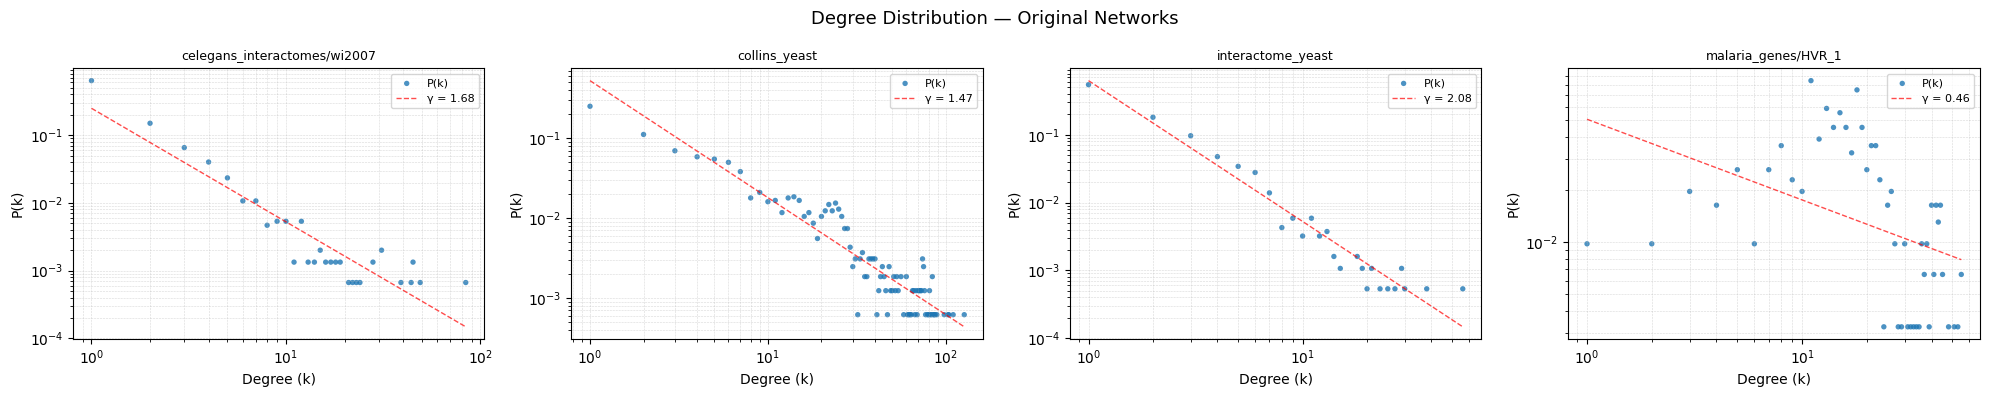

In [97]:
plot_degree_distribution_loglog(datasets["biological"])

In [98]:
for n in datasets["biological"]:
    G_temp = n["networks"]["original"][0]

    n["networks"].update(
        generate_random_networks_from_graph(G_temp)
    )

In [99]:
print_total_gen_networks(datasets["biological"])

+------------------------------+-------------------+-----------------------+---------------+--------------------------+------------------+
| network                      |   barabasi_albert |   configuration_model |   erdos_renyi |   stochastic_block_model |   watts_strogatz |
|------------------------------+-------------------+-----------------------+---------------+--------------------------+------------------|
| celegans_interactomes/wi2007 |                36 |                    18 |            18 |                       27 |               36 |
| collins_yeast                |                36 |                    18 |            18 |                       27 |               36 |
| interactome_yeast            |                36 |                    18 |            18 |                       27 |               36 |
| malaria_genes/HVR_1          |                36 |                    10 |            18 |                       27 |               36 |
+--------------------------

In [100]:
features = []
for networks in datasets["biological"]:
    for net_id in networks["networks"]:
        for net in networks["networks"][net_id]:
            tmp = feature_extractor(net)
            tmp.update(
                {
                    "type": net_id,
                    "network": networks["name"]
                }
            )
            features.append(tmp)

In [101]:
df_biological =  pd.DataFrame(features)
df_biological = df_biological[list(df_biological.columns[-2:]) + list(df_biological.columns[:-2])]

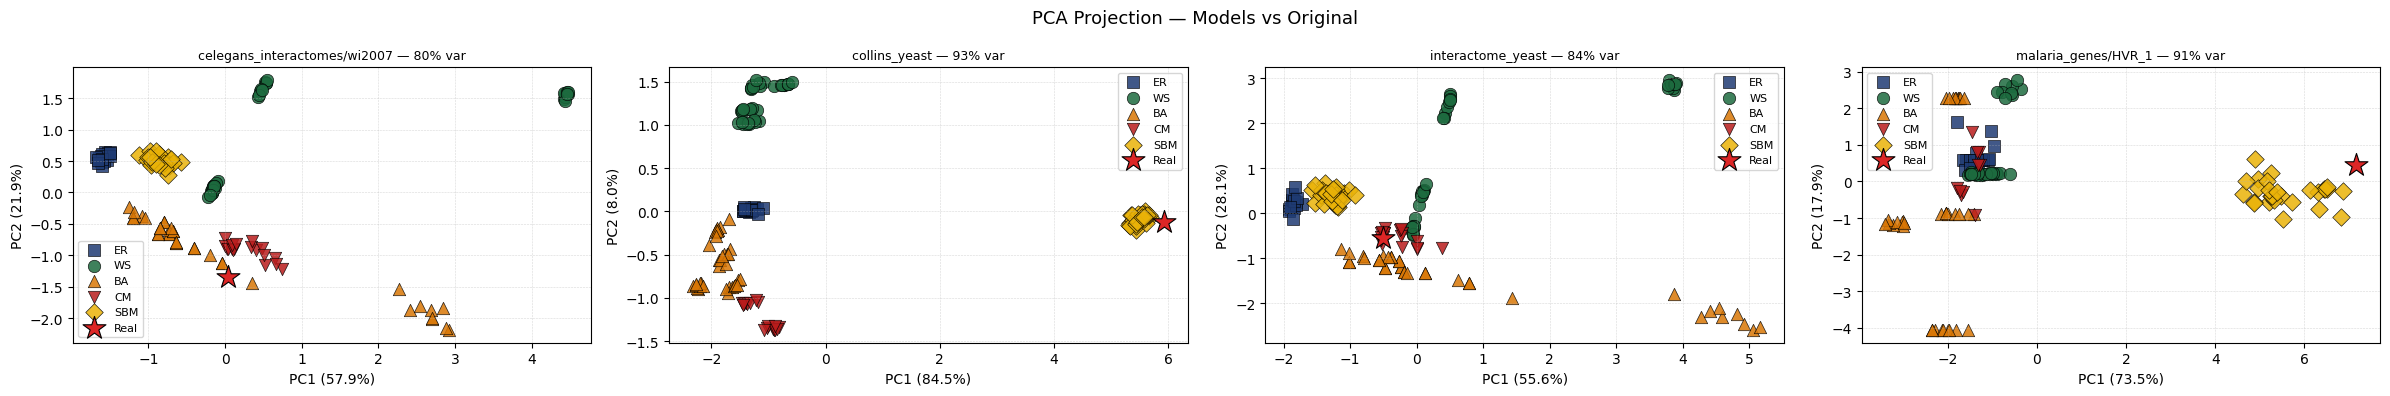

In [102]:
plot_pca_projection(df_biological)

In [103]:
res = []
res.extend(classify(df_biological, datasets["biological"][0]["name"]))
res.extend(classify(df_biological, datasets["biological"][1]["name"]))
res.extend(classify(df_biological, datasets["biological"][2]["name"]))
res.extend(classify(df_biological, datasets["biological"][3]["name"]))


df_biological_res = pd.DataFrame(res)
df_biological_res

,method,network,predicted,confidence
0,knn,celegans_interactomes/wi2007,configuration_model,1.0000
1,centroid,celegans_interactomes/wi2007,barabasi_albert,0.2504
2,knn,collins_yeast,stochastic_block_model,1.0000
3,centroid,collins_yeast,stochastic_block_model,0.8382
4,knn,interactome_yeast,stochastic_block_model,1.0000
5,centroid,interactome_yeast,barabasi_albert,0.0099
6,knn,malaria_genes/HVR_1,stochastic_block_model,1.0000
7,centroid,malaria_genes/HVR_1,stochastic_block_model,0.7777


## Social Networks
<a id="social"></a>

In [104]:
for n in datasets["social"]:
    temp = download_xml_zst(n["path"])
    n["networks"]  = {
        "original": 
        [read_xml_zst_to_networkx(
            temp,
            relabel_to_int=True
        )]
    }
    print(
        n["networks"]["original"][0]
    )

Graph named 'netscience' with 1589 nodes and 2742 edges
Graph named 'crime' with 1380 nodes and 1476 edges
Graph named 'foursquare (NYC_restaurant_checkin)' with 4936 nodes and 13472 edges
Graph named 'foursquare (NYC_restaurant_tips)' with 6410 nodes and 9472 edges


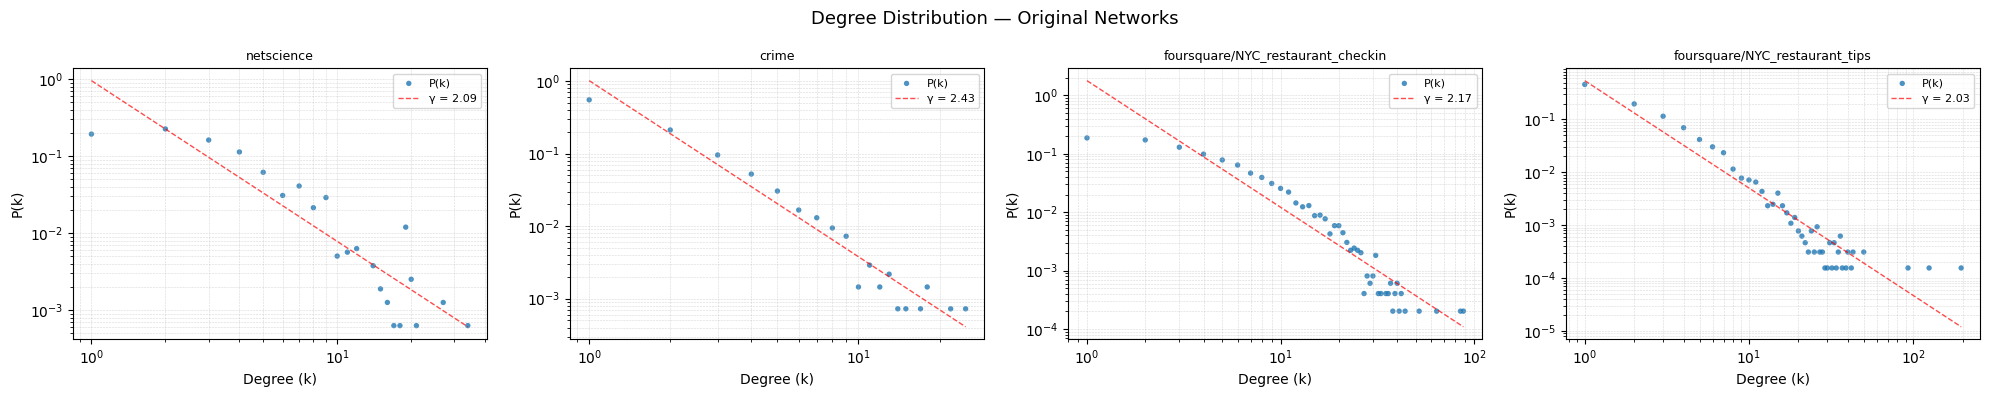

In [105]:
plot_degree_distribution_loglog(datasets["social"])

In [106]:
for n in datasets["social"]:
    G_temp = n["networks"]["original"][0]

    n["networks"].update(
        generate_random_networks_from_graph(G_temp)
    )

In [ ]:
print_total_gen_networks(datasets["social"])

+------------------------------+-------------------+-----------------------+---------------+--------------------------+------------------+
| network                      |   barabasi_albert |   configuration_model |   erdos_renyi |   stochastic_block_model |   watts_strogatz |
|------------------------------+-------------------+-----------------------+---------------+--------------------------+------------------|
| celegans_interactomes/wi2007 |                36 |                    18 |            18 |                       27 |               36 |
| collins_yeast                |                36 |                    18 |            18 |                       27 |               36 |
| interactome_yeast            |                36 |                    18 |            18 |                       27 |               36 |
| malaria_genes/HVR_1          |                36 |                    10 |            18 |                       27 |               36 |
+--------------------------

In [121]:
jobs = [
    (net, net_id, networks["name"])
    for networks in datasets["social"]
    for net_id, nets in networks["networks"].items()
    for net in nets
]

with ProcessPoolExecutor(max_workers=6) as executor:
    features_job = list(executor.map(extract_feature_job, jobs))

In [122]:
df_social =  pd.DataFrame(features_job)
df_social = df_social[list(df_social.columns[-2:]) + list(df_social.columns[:-2])]

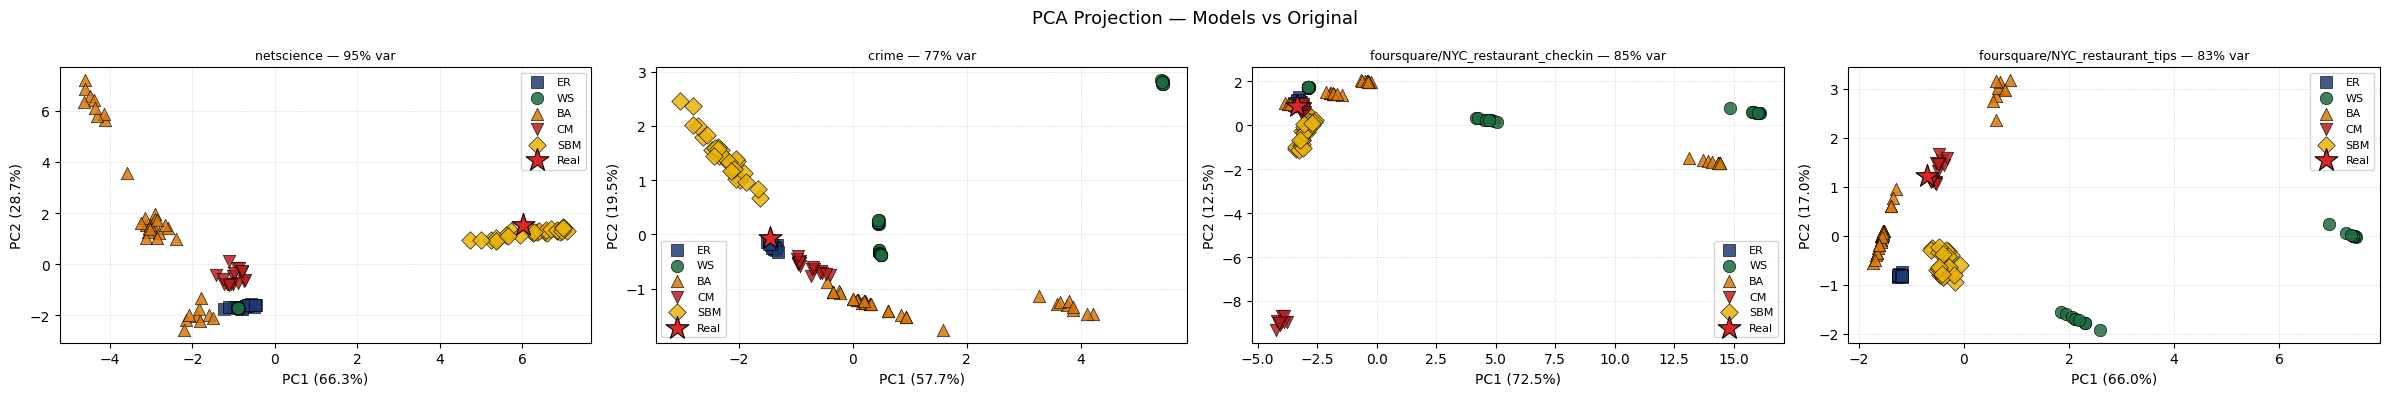

In [123]:
plot_pca_projection(df_social)

In [124]:
res = []
res.extend(classify(df_social, datasets["social"][0]["name"]))
res.extend(classify(df_social, datasets["social"][1]["name"]))
res.extend(classify(df_social, datasets["social"][2]["name"]))
res.extend(classify(df_social, datasets["social"][3]["name"]))


df_social_res = pd.DataFrame(res)
df_social_res

,method,network,predicted,confidence
0,knn,netscience,stochastic_block_model,1.0000
1,centroid,netscience,stochastic_block_model,0.8729
2,knn,crime,erdos_renyi,0.6000
3,centroid,crime,erdos_renyi,0.0400
4,knn,foursquare/NYC_restaurant_checkin,configuration_model,1.0000
5,centroid,foursquare/NYC_restaurant_checkin,erdos_renyi,0.5087
6,knn,foursquare/NYC_restaurant_tips,configuration_model,1.0000
7,centroid,foursquare/NYC_restaurant_tips,configuration_model,0.7194


## Technological Networks
<a id="tech"></a>

In [125]:
for n in datasets["technological"]:
    temp = download_xml_zst(n["path"])
    n["networks"]  = {
        "original": 
        [read_xml_zst_to_networkx(
            temp,
            relabel_to_int=True
        )]
    }
    print(
        n["networks"]["original"][0]
    )

Graph named 'internet_as' with 22963 nodes and 48436 edges
Graph named 'jdk' with 6434 nodes and 53658 edges
Graph named 'gnutella (04)' with 10879 nodes and 39994 edges


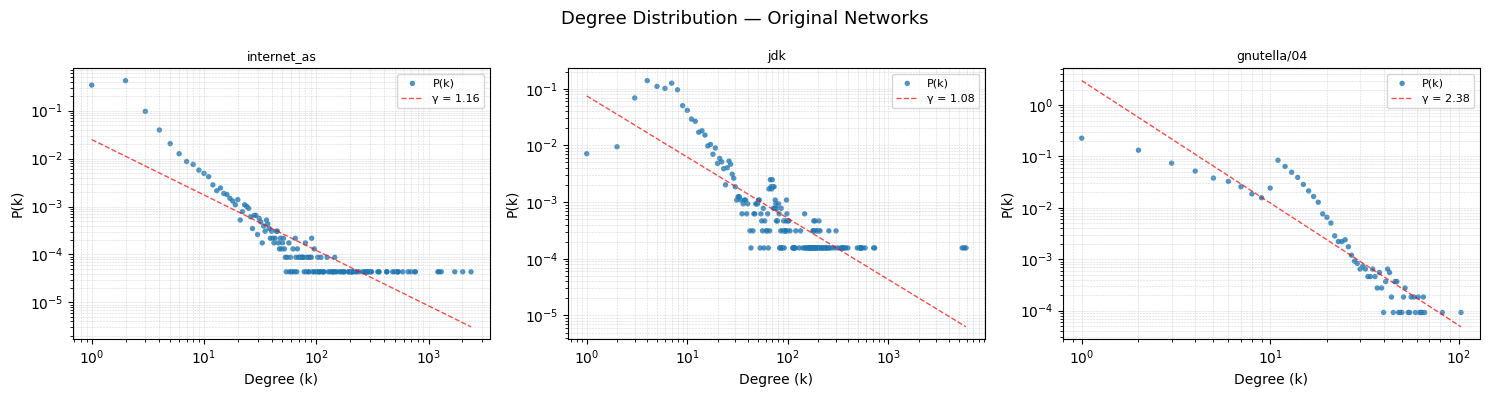

In [126]:
plot_degree_distribution_loglog(datasets["technological"])

In [127]:
for n in datasets["technological"]:
    G_temp = n["networks"]["original"][0]

    n["networks"].update(
        generate_random_networks_from_graph(G_temp)
    )

In [128]:
print_total_gen_networks(datasets["technological"])

+-------------+-------------------+-----------------------+---------------+--------------------------+------------------+
| network     |   barabasi_albert |   configuration_model |   erdos_renyi |   stochastic_block_model |   watts_strogatz |
|-------------+-------------------+-----------------------+---------------+--------------------------+------------------|
| gnutella/04 |                36 |                    18 |            18 |                       27 |               36 |
| internet_as |                20 |                     5 |            10 |                       15 |               20 |
| jdk         |                36 |                     9 |            18 |                       27 |               36 |
+-------------+-------------------+-----------------------+---------------+--------------------------+------------------+


In [129]:
jobs = [
    (net, net_id, networks["name"])
    for networks in datasets["technological"]
    for net_id, nets in networks["networks"].items()
    for net in nets
]

with ProcessPoolExecutor(max_workers=6) as executor:
    features_job = list(executor.map(extract_feature_job, jobs))

In [133]:
df_technological =  pd.DataFrame(features_job)
df_technological = df_technological[list(df_technological.columns[-2:]) + list(df_technological.columns[:-2])]

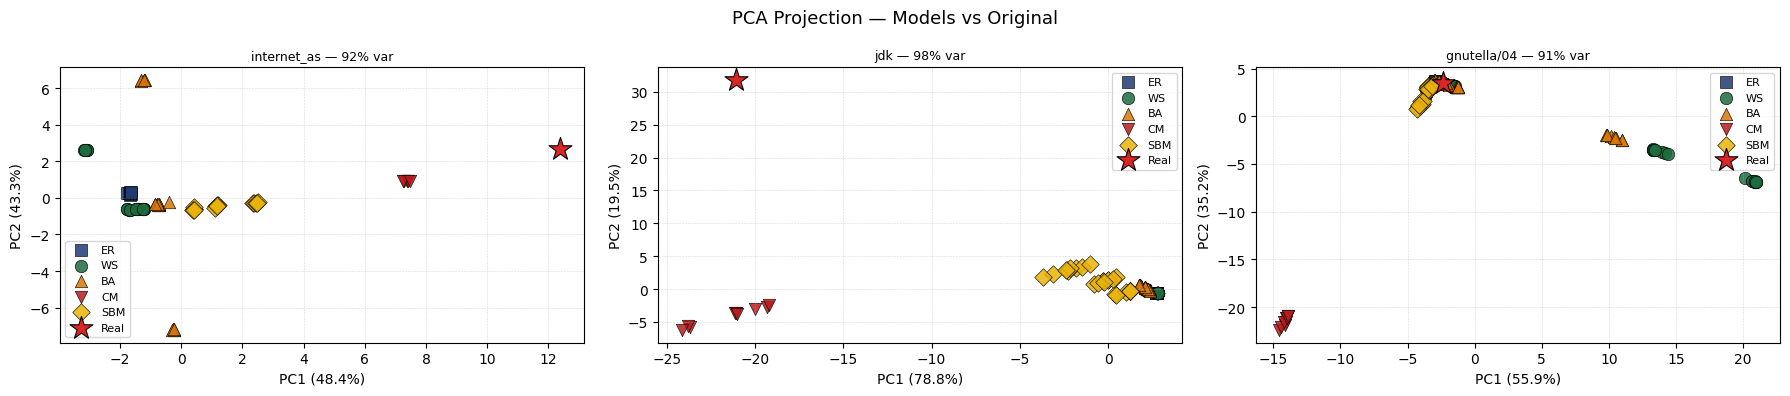

In [134]:
plot_pca_projection(df_technological)

In [135]:
res = []
res.extend(classify(df_technological, datasets["technological"][0]["name"]))
res.extend(classify(df_technological, datasets["technological"][1]["name"]))
res.extend(classify(df_technological, datasets["technological"][2]["name"]))


df_technological_res = pd.DataFrame(res)
df_technological_res

,method,network,predicted,confidence
0,knn,internet_as,configuration_model,1.0000
1,centroid,internet_as,configuration_model,0.4084
2,knn,jdk,stochastic_block_model,1.0000
3,centroid,jdk,stochastic_block_model,0.0611
4,knn,gnutella/04,configuration_model,1.0000
5,centroid,gnutella/04,erdos_renyi,0.7145


## Resultados
<a id="results"></a>

### Redes Geradas

Em vez de criar apenas um grafo representativo para cada modelo, optei por gerar múltiplas redes aleatórias para cada entrada. A ideia aqui foi **amostrar o espaço de cada modelo**, permitindo que o classificador compare a rede original contra uma "nuvem" de variações, em vez de um único ponto estático. Para garantir diversidade, utilizei diferentes *seeds* e variantes para os cinco modelos clássicos abaixo:

* **erdos_renyi:** Funciona como o nosso **marco zero (null baseline)**. São grafos com arestas independentes e probabilidade de conexão uniforme. O resultado é uma distribuição de graus homogênea (Poisson), sem clusters ou comunidades — basicamente como a rede seria se não houvesse nenhuma organização além da densidade.
* **configuration_model:** Este modelo preserva a sequência exata de graus da rede original, mas faz a religação aleatória das arestas. Ele captura distribuições de cauda pesada, mas destrói agrupamentos e comunidades. Usei duas versões: a clássica (com limpeza de loops) e a `expected_degree_graph`.
* **barabasi_albert:** Focado em crescimento e anexação preferencial. Novos nós se conectam aos antigos proporcionalmente ao grau destes, gerando naturalmente distribuições "scale-free". Variei o parâmetro de anexação e incluí o `powerlaw_cluster_graph` para adicionar fechamento de triângulos.
* **watts_strogatz:** Parte de uma rede regular e aplica religações aleatórias. Calibrei o parâmetro $p$ para reproduzir o coeficiente de agrupamento da rede original. É o modelo ideal para testar o comportamento de "mundo pequeno" (alto clustering e caminhos curtos).
* **stochastic_block_model:** Focado em comunidades com probabilidades internas e externas de conexão. As comunidades foram detectadas via Louvain na rede original (em três resoluções), e a estrutura interna foi reproduzida para preservar hubs dentro dos blocos.

No total, cada rede de entrada gerou entre 100 e 135 grafos sintéticos para alimentar o classificador.

### Classificadores

Escolhi modelos que **dispensam treinamento prévio**, considerando o tempo do projeto e o volume de dados por rede. Ambos operam no espaço de atributos extraído pelo `feature_extractor`, após padronização com `RobustScaler` (que lida melhor com dispersões desiguais). Removi os atributos de "nós" e "arestas" por serem constantes ou redundantes em relação ao `k1`.

* **KNN (k-Nearest Neighbors, k=5):** Calcula a distância média da rede original para as 5 realizações mais próximas de cada classe. A classe com a menor distância média vence. O score de confiança indica o quanto a rede original está decisivamente perto de uma classe em comparação à segunda melhor opção. Ele foca na **estrutura local**.
* **Centroid:** Mede a distância euclidiana da rede original até o centroide (média) de cada classe no espaço de atributos. Representa a posição típica de cada cluster, ignorando variações locais. Ele foca na **estrutura global**.

Esses classificadores são **complementares**: se ambos concordam com confiança alta, o resultado é robusto. Se divergem, temos um sinal claro de ambiguidade — ou a rede está entre duas classes, ou nenhum modelo a descreve bem.

---

### Redes Biológicas

Analisei quatro redes derivadas de diferentes técnicas experimentais. A intenção foi testar a hipótese de que o **método de coleta determina a classe topológica da rede**, muitas vezes de forma mais forte que a própria biologia do organismo ([Hakes et al., 2008](https://doi.org/10.1371/journal.pcbi.1000232)).

* **[celegans_interactomes/wi2007](https://networks.skewed.de/net/celegans_interactomes)** — Interações proteína-proteína extraídas via **Yeast Two-Hybrid (Y2H)**, que foca em ligações binárias diretas.
* **[collins_yeast](https://networks.skewed.de/net/collins_yeast)** — Interações medidas por **AP/MS** (purificação por afinidade). Este método captura complexos proteicos inteiros, gerando redes com cliques densos.
* **[interactome_yeast](https://networks.skewed.de/net/interactome_yeast)** — Um interactoma consolidado que mistura Y2H (predominante) com AP/MS e curadoria.
* **[malaria_genes/HVR_1](https://networks.skewed.de/net/malaria_genes)** — Rede de genes do parasita da malária. As arestas indicam **similaridade de sequência genética**, não interação física.

#### Resultados de Classificação

| método | rede | predição | confiança |
| --- | --- | --- | --- |
| knn | celegans_interactomes/wi2007 | configuration_model | 1.0000 |
| centroid | celegans_interactomes/wi2007 | barabasi_albert | 0.2504 |
| knn | collins_yeast | stochastic_block_model | 1.0000 |
| centroid | collins_yeast | stochastic_block_model | 0.8382 |
| knn | interactome_yeast | stochastic_block_model | 1.0000 |
| centroid | interactome_yeast | barabasi_albert | 0.0099 |
| knn | malaria_genes/HVR_1 | stochastic_block_model | 1.0000 |
| centroid | malaria_genes/HVR_1 | stochastic_block_model | 0.7777 |

#### Interpretação

No caso da **collins_yeast**, a classificação como SBM foi unânime e confiante. Isso faz sentido: a captura de complexos proteicos gera comunidades densas e alta assortatividade ([Collins et al., 2007](https://doi.org/10.1074/mcp.M600381-MCP200)). O SBM, ao modelar blocos modulares, é estruturalmente consistente com esse método de coleta ([Yu et al., 2008](https://doi.org/10.1126/science.1158684)).

Na rede **celegans/wi2007**, os classificadores divergiram entre CM e BA. Isso é esperado em redes esparsas de Y2H, onde o traço dominante é a cauda pesada na distribuição de graus. Nessa zona de baixa densidade, **CM e BA tornam-se quase indistinguíveis** topologicamente; o resultado depende apenas de quais atributos dominam a métrica (vizinhunça local vs. centro de massa).

Já a **interactome_yeast** apresentou uma confiança de centroide de apenas 0.01, indicando um empate técnico entre SBM e BA. É um caso clássico de borda: como a rede mistura fontes Y2H (assinatura BA) com AP/MS (assinatura SBM), a topologia resultante é híbrida, e o classificador reporta essa incerteza de forma honesta.

Por fim, a rede de **malaria_genes** caiu no SBM, mas é claramente um caso **fora da curva (OOD)**. Redes de similaridade têm um mecanismo gerador geométrico — os genes se ligam por proximidade no espaço de sequências. Isso gera métricas que nenhum dos cinco modelos nulos captura perfeitamente, e o SBM foi escolhido por ser o "menos distante".

---

### Redes Sociais

Aqui, a topologia é moldada pela **natureza da interação**: colaboração, associação criminosa ou comportamento de consumo.

* **[netscience](https://networks.skewed.de/net/netscience)** — Coautoria entre cientistas. É movida por comunidades: pesquisadores colaboram muito dentro de seus campos e criam pontes esparsas entre subfields.
* **[crime](https://networks.skewed.de/net/crime)** — Associações entre suspeitos e vítimas em St. Louis. É uma rede esparsa gerada por amostragem "bola de neve" a partir de cinco homicídios iniciais.
* **[foursquare/NYC_restaurant_checkin](https://networks.skewed.de/net/foursquare)** — Rede bipartida de usuários e locais. A projeção gera caudas pesadas, mas pouca estrutura de comunidade entre usuários.
* **[foursquare/NYC_restaurant_tips](https://networks.skewed.de/net/foursquare)** — Similar à de check-ins, mas baseada em comentários (tips), o que a torna muito mais esparsa.

#### Resultados de Classificação

| método | rede | predição | confiança |
| --- | --- | --- | --- |
| knn | netscience | stochastic_block_model | 1.0000 |
| centroid | netscience | stochastic_block_model | 0.8729 |
| knn | crime | erdos_renyi | 0.6000 |
| centroid | crime | erdos_renyi | 0.0400 |
| knn | foursquare/NYC_restaurant_checkin | configuration_model | 1.0000 |
| centroid | foursquare/NYC_restaurant_checkin | erdos_renyi | 0.5087 |
| knn | foursquare/NYC_restaurant_tips | configuration_model | 1.0000 |
| centroid | foursquare/NYC_restaurant_tips | configuration_model | 0.7194 |

#### Interpretação

A rede **netscience** foi um "caso de livro" para o SBM. A concordância alta entre os classificadores reflete a realidade das redes de coautoria: clusters densos vinculados por colaborações interdisciplinares esparsas ([Newman, 2001](https://doi.org/10.1073/pnas.98.2.404)).

Já na rede **crime**, a confiança baixíssima indica que **nenhum modelo se ajusta bem**. Isso ocorre porque a topologia reflete o **processo de amostragem policial**, não uma estrutura social orgânica. O snowball sampling a partir de poucas *seeds* gera estruturas em árvore que lembram superficialmente ER, mas são na verdade artefatos da coleta ([Stumpf, Wiuf & May, 2005](https://doi.org/10.1073/pnas.0501179102)).

Nas redes do **foursquare**, a divergência no caso de check-ins reflete a natureza bipartida dos dados: a projeção cria a cauda pesada do CM, mas a falta de comunidades reais entre usuários a puxa para o ER. Na rede de **tips**, que é mais esparsa e "limpa", a distribuição de graus domina o sinal, levando à classificação clara como CM.

---

### Redes Tecnológicas

Analisamos infraestrutura física (**internet_as**), arquitetura de software (**jdk**) e redes peer-to-peer (**gnutella/04**).

#### Resultados de Classificação

| método | rede | predição | confiança |
| --- | --- | --- | --- |
| knn | internet_as | configuration_model | 1.0000 |
| centroid | internet_as | configuration_model | 0.4084 |
| knn | jdk | stochastic_block_model | 1.0000 |
| centroid | jdk | stochastic_block_model | 0.0611 |
| knn | gnutella/04 | configuration_model | 1.0000 |
| centroid | gnutella/04 | erdos_renyi | 0.7145 |

#### Interpretação

Na **internet_as**, o CM foi escolhido por preservar a distribuição de graus, mas a confiança moderada sinaliza que algo falta. O modelo CM não captura o fenômeno do **rich-club**, onde hubs de alto grau se conectam densamente entre si ([Zhou & Mondragón, 2004](https://doi.org/10.1109/LCOMM.2004.823426)). O classificador fez a escolha "menos errada" dentro das opções disponíveis.

A rede **jdk** apresentou uma ambiguidade quase total (confiança 0.06). Isso acontece porque o software tem duas propriedades coexistentes: comunidades arquitetônicas (pacotes) e hubs globais (classes como `Object`). O classificador oscila entre SBM e CM/BA, o que é coerente com a literatura sobre redes de software hierárquicas ([Valverde & Solé, 2002](https://arxiv.org/abs/cond-mat/0204344)).

Em **gnutella/04**, a divergência entre CM e ER reflete a ausência de uma autoridade central. A conectividade é majoritariamente aleatória (ER), mas a heterogeneidade no tempo de atividade dos nós introduz uma leve cauda pesada (CM).

---

### Hipótese: Redes do mesmo tipo seguem o mesmo modelo?

**Resposta Curta:** Não.

**Razão:** O **mecanismo gerador das arestas** (método experimental ou princípio de interação) é um preditor muito mais forte do que a categoria temática. Redes biológicas mudam de classe dependendo se usamos Y2H ou AP/MS ([Hakes et al., 2008](https://doi.org/10.1371/journal.pcbi.1000232); [Yu et al., 2008](https://doi.org/10.1126/science.1158684)). Redes tecnológicas variam de acordo com o design — seja ele físico, arquitetural ou de protocolo.

Em suma, as redes mostram que "social" ou "biológico" são apenas rótulos; o que define a topologia é a regra mecânica por trás de cada conexão. Modelos mais complexos, como **Hierarchical Random Graphs** ([Clauset, Moore & Newman, 2008](https://doi.org/10.1038/nature06830)) ou **Forest Fire** ([Leskovec, Kleinberg & Faloutsos, 2005](https://doi.org/10.1145/1081870.1081893)), poderiam ser o próximo passo para capturar o que os modelos clássicos deixaram escapar.